That is an excellent milestone! **Decision Trees** are one of the most intuitive machine learning models because they mimic how humans make decisions. Whether you are deciding what to eat or if a bank should approve a loan, you are essentially following a "tree" of logic.

Since you are diving into the math (Entropy, Gini, Information Gain), here is a step-by-step guide to how the tree actually "grows."

---

## 1. The Anatomy of a Tree

A Decision Tree is made of three main parts:

* **Root Node:** The very first question (e.g., "Is the person's credit score > 700?"). This is the most important feature.
* **Decision Nodes:** The middle questions that split the data further.
* **Leaf Nodes:** The final answer (e.g., "Approve Loan" or "Reject Loan"). No more splitting happens here.

---

## 2. How the Tree "Thinks" (The Strategy)

The tree uses a strategy called **Recursive Partitioning**. It wants to create "Pure" leaves.

* **Pure:** A leaf where 100% of the items belong to one class.
* **Impure:** A leaf that is still a 50/50 mix.

The tree will look at every column in your data (Age, Income, Education) and calculate which one gives the **Highest Information Gain**. It picks that one as the split and repeats the process until the leaves are pure or a limit is reached.

---

## 3. The "Battle" of Metrics: Gini vs. Entropy

You previously asked about these. Most people ask: "Which one should I use?"

* **Gini Impurity:** It is faster to calculate (no logarithms). Scikit-Learn uses this by default. It focuses on reducing "misclassification."
* **Entropy:** It is slightly slower but more sensitive to changes in class probabilities. It focuses on reducing "disorder."

**The Truth:** In 95% of cases, both metrics will give you the exact same tree. Don't stress too much over choosing between them!

---

## 4. The Biggest Danger: Overfitting

Because Decision Trees are "Non-parametric" and "Greedy," they will try to keep splitting until every single data point has its own leaf. This is called **Overfitting**. The tree becomes so specific to your training data that it fails on new, real-world data.

### How to stop it (Hyperparameters):

* **max_depth:** Tell the tree to stop after 3 or 5 levels.
* **min_samples_split:** Tell the tree "Don't split this node unless there are at least 10 people in it."
* **Pruning:** Cutting off branches that don't add much value (Information Gain $\approx$ 0).

---

## 5. Why are Decision Trees so Popular?

1. **Interpretability:** You can literally print the tree and show it to a manager. They will understand the logic.
2. **No Scaling Needed:** Unlike Linear Regression or KNN, Decision Trees don't care if your data is $0–1$ or $0–1,000,000$.
3. **Handles Everything:** It works with both numbers (Regression) and categories (Classification).

---

**Would you like me to show you how to visualize a tree in Python using `plot_tree` so you can actually see the "If-Then" logic of your model?**

To understand these three terms, you have to think like a **Decision Tree**. A Decision Tree’s only goal is to take a messy mix of data and split it into groups that are as "pure" as possible (e.g., all Apples in one bucket, all Oranges in another).

These metrics are the "rulers" we use to measure how messy those buckets are.

Entropy is a fundamental physical quantity, denoted by S, that measures the degree of disorder, randomness, or unavailability of energy to do work within a system. It is central to the second law of thermodynamics, which states that the total entropy of an isolated system always increases over time, dictating that natural processes are irreversible and move towards equilibrium.

---

### 1. Entropy (The "Chaos" Meter)

Entropy comes from information theory. It measures the level of **disorder** or **uncertainty** in a group.

* **How it works:** * If a bucket has 50% Class A and 50% Class B, Entropy is **1.0** (Maximum chaos/Perfectly mixed).
* If a bucket has 100% Class A and 0% Class B, Entropy is **0.0** (Zero chaos/Perfectly pure).


* **Your Value (0.971):** This is very close to 1.0. It means your dataset is currently a "jumbled mess" where the classes are almost evenly mixed.

---

### 2. Gini Impurity (The "Mistake" Probability)

Gini is the default metric used by the **CART** algorithm (Scikit-Learn's default). It measures the probability that a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

* **How it works:**
* **0.0** means the node is "Pure" (all one class).
* **0.5** (for binary classes) is the "Dirtiest" it can be.


* **Your Value (0.48):** Since 0.5 is the worst possible score for two classes, your score of 0.48 tells us the dataset is almost perfectly impure. If you closed your eyes and guessed the class, you'd be wrong nearly half the time.

---

### 3. Information Gain (The "Success" Score)

Information Gain is the **difference** in entropy before and after you make a split. It tells you: *"How much did I clean up the mess?"*

* **The Formula:** $Information\ Gain = Entropy_{before} - Entropy_{after}$
* **Your Value (0.0):** This is a "Fail." It means that after you split the data using a specific feature, the two new buckets were **just as messy** as the original one.
* *Example:* If you try to separate "Boys" from "Girls" based on "Number of legs," everyone has 2 legs. The split doesn't help you distinguish them at all. Information Gain = 0.



---

### Summary Table: Comparing the Three

| Metric | Ideal Value (Pure) | Worst Value (Mixed) | Simple Definition |
| --- | --- | --- | --- |
| **Entropy** | 0.0 | 1.0 | How much "information" or "surprise" is in the data? |
| **Gini Impurity** | 0.0 | 0.5 | What is the chance of a random misclassification? |
| **Information Gain** | **Higher is Better** | 0.0 | How much did this split help me separate the classes? |

---

### Why does this matter for you?

When you build a Decision Tree, the computer calculates the **Information Gain** for every single column in your data. It will choose the column with the **highest** Information Gain to be the "Root" (the first split) of your tree.

**Would you like me to show you a small manual calculation (like a 4-row dataset) so you can see exactly where these numbers come from?**

Since you are learning **Decision Trees**, the best way to truly "get it" is to see the code and the visualization side-by-side.

In your data science workflow (especially for your portfolio projects), being able to explain *why* a model made a decision is just as important as the accuracy score.

### 1. Simple Python Implementation

Here is how you would build a tree and visualize its logic using `scikit-learn`.

```python
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Load data (Iris dataset is a classic for learning)
iris = load_iris()
X, y = iris.data, iris.target

# 2. Initialize the model 
# We set max_depth=3 to prevent the tree from becoming too complex (Overfitting)
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 3. Train the model
clf.fit(X, y)

# 4. Visualize the Tree
plt.figure(figsize=(15,10))
plot_tree(clf, 
          filled=True, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names,
          rounded=True)
plt.show()

```

---

### 2. How to Read the Output

When you look at the visualization above, each box (node) tells a story:

* **The Top Line:** The "Question" being asked (e.g., `petal width (cm) <= 0.8`).
* **Gini:** The impurity score we discussed earlier. Notice how it gets closer to **0.0** as you move down the tree.
* **Samples:** How many data points are currently in that "bucket."
* **Value:** How many items of each class are in that bucket (e.g., `[50, 0, 0]` means 50 of Class A, 0 of B, 0 of C).
* **Class:** The majority class in that node.

---

### 3. Your Next Big Step: Random Forest

Once you feel comfortable with a single Decision Tree, your next move should be **Random Forest**.

* **The Concept:** A single tree can be "fragile" (sensitive to small changes in data). A Random Forest grows **hundreds of trees** (a forest) and lets them "vote" on the final answer.
* **Why it's better:** It is much more powerful and harder to overfit.

---

### Summary Checklist for Mastering Trees:

1. **Understand the Split:** Practice calculating Gini/Entropy by hand for a small 4-row table.
2. **Control the Growth:** Experiment with `max_depth` and `min_samples_leaf` to see how the tree shape changes.
3. **Visualize:** Always plot your tree! If it looks like a giant, messy spiderweb, it's probably overfitted.

**Would you like me to give you a small 5-row dataset and walk you through calculating the Gini Impurity for it step-by-step?**

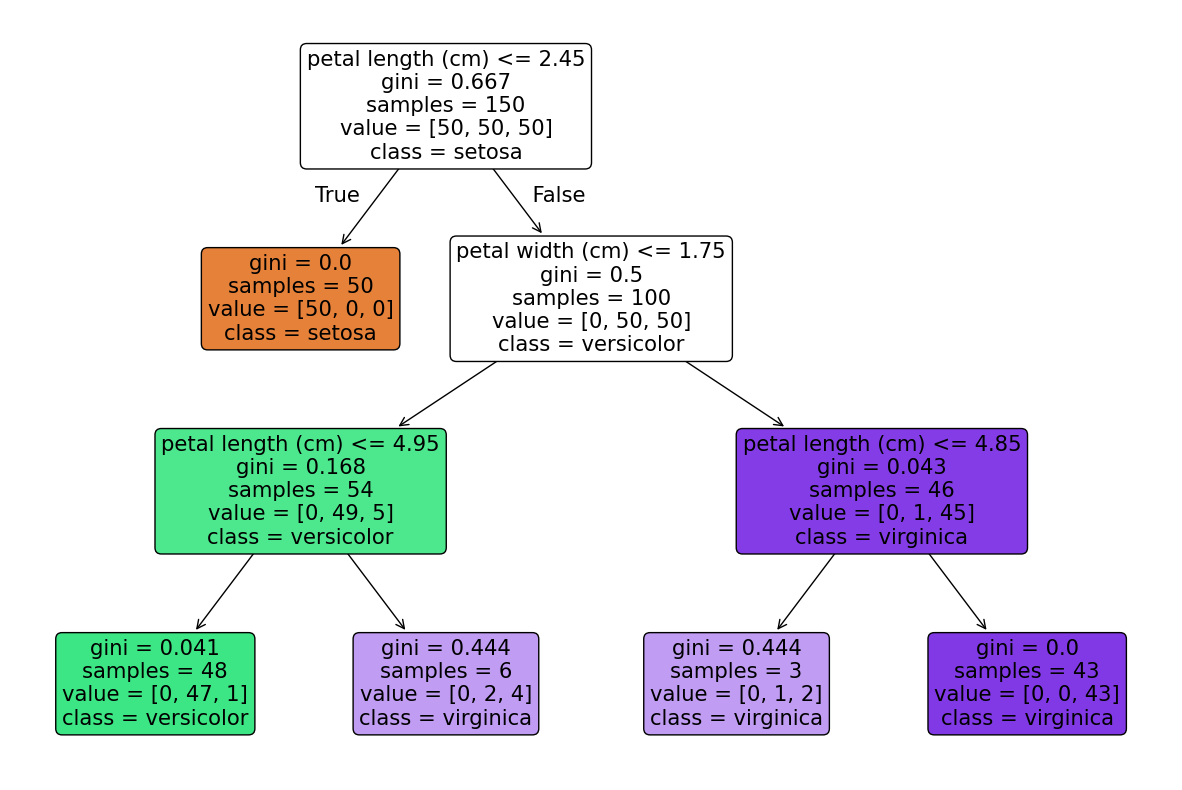

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Load data (Iris dataset is a classic for learning)
iris = load_iris()
X, y = iris.data, iris.target

# 2. Initialize the model 
# We set max_depth=3 to prevent the tree from becoming too complex (Overfitting)
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 3. Train the model
clf.fit(X, y)

# 4. Visualize the Tree
plt.figure(figsize=(15,10))
plot_tree(clf, 
          filled=True, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names,
          rounded=True)
plt.show()